# ACV Satellite Monitoring

Classificação de imagens de satélite para monitoramento de queimadas florestais.

# 1. Introdução

Este projeto utiliza o dataset Sen2Fire para classificação de imagens de satélite contendo áreas com queimadas florestais.

Objetivos:

- Explorar a estrutura do dataset.
- Construir um dataset de classificação binária.
- Treinar diferentes arquiteturas CNN.
- Comparar os resultados obtidos.

In [47]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [48]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# 2. Configuração do Projeto

Definição dos diretórios utilizados durante o desenvolvimento.

In [49]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("Processed dir:", PROCESSED_DIR)

Project root: c:\Projetos\acv-satellite-monitoring
Raw dir: c:\Projetos\acv-satellite-monitoring\data\raw
Processed dir: c:\Projetos\acv-satellite-monitoring\data\processed


# 3. Exploração Inicial do Dataset

Nesta etapa é realizada uma inspeção da estrutura dos arquivos do dataset Sen2Fire.

In [50]:
SEN2FIRE_DIR = RAW_DIR / "sen2fire"
print(SEN2FIRE_DIR)
print(list(SEN2FIRE_DIR.iterdir())[:10])

c:\Projetos\acv-satellite-monitoring\data\raw\sen2fire
[WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1'), WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene2'), WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene3'), WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene4')]


In [51]:
npz_files = list(SEN2FIRE_DIR.rglob("*.npz"))
len(npz_files), npz_files[:5]

(2466,
 [WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1/scene_1_patch_10_1.npz'),
  WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1/scene_1_patch_10_10.npz'),
  WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1/scene_1_patch_10_11.npz'),
  WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1/scene_1_patch_10_12.npz'),
  WindowsPath('c:/Projetos/acv-satellite-monitoring/data/raw/sen2fire/scene1/scene_1_patch_10_13.npz')])

In [52]:
sample = np.load(npz_files[0], allow_pickle=True)
sample.files

['image', 'aerosol', 'label']

In [53]:
for key in sample.files:
    arr = sample[key]
    print(f"{key}: type={type(arr)}, shape={arr.shape}, dtype={arr.dtype}")

image: type=<class 'numpy.ndarray'>, shape=(12, 512, 512), dtype=int16
aerosol: type=<class 'numpy.ndarray'>, shape=(512, 512), dtype=float32
label: type=<class 'numpy.ndarray'>, shape=(512, 512), dtype=uint8


In [54]:
image = sample["image"]
aerosol = sample["aerosol"]
label = sample["label"]

print("image min/max:", image.min(), image.max())
print("aerosol min/max:", aerosol.min(), aerosol.max())

image min/max: 23 5932
aerosol min/max: -0.973645 -0.40636337


In [55]:
print("Valores únicos no label:", np.unique(label))
print("Quantidade de pixels > 0:", (label > 0).sum())
print("Total de pixels:", label.size)
print("Percentual de pixels com fogo:", (label > 0).sum() / label.size * 100)

Valores únicos no label: [0]
Quantidade de pixels > 0: 0
Total de pixels: 262144
Percentual de pixels com fogo: 0.0


In [56]:
has_fire = int((label > 0).any())
print("Patch com fogo?", has_fire)

Patch com fogo? 0


In [57]:
fire_flags = []

for file_path in npz_files:
    with np.load(file_path, allow_pickle=True) as data:
        label = data["label"]
        fire_flags.append(int((label > 0).any()))

fire_flags = np.array(fire_flags)

print("Total de patches:", len(fire_flags))
print("Patches com fogo:", fire_flags.sum())
print("Patches sem fogo:", (fire_flags == 0).sum())
print("Percentual com fogo:", fire_flags.mean() * 100)

Total de patches: 2466
Patches com fogo: 349
Patches sem fogo: 2117
Percentual com fogo: 14.152473641524738


In [58]:
scene_df = pd.DataFrame(
    [
        (scene, fire, count)
        for (scene, fire), count in scene_counts.items()
    ],
    columns=["scene", "has_fire", "count"]
)

scene_df.sort_values(["scene", "has_fire"])

,scene,has_fire,count
0,scene1,0,749
1,scene1,1,115
2,scene2,0,556
3,scene2,1,38
4,scene3,0,410
5,scene3,1,94
6,scene4,0,402
7,scene4,1,102


In [59]:
df = pd.DataFrame({
    "file_path": [str(p) for p in npz_files],
    "has_fire": fire_flags,
    "scene": [p.parent.name for p in npz_files]
})

df.head()

,file_path,has_fire,scene
0,c:\Projetos\acv-satellite-monitoring\data\raw\...,0,scene1
1,c:\Projetos\acv-satellite-monitoring\data\raw\...,1,scene1
2,c:\Projetos\acv-satellite-monitoring\data\raw\...,1,scene1
3,c:\Projetos\acv-satellite-monitoring\data\raw\...,1,scene1
4,c:\Projetos\acv-satellite-monitoring\data\raw\...,1,scene1


In [60]:
print(df.shape)
print(df["has_fire"].value_counts())
print(df.groupby("scene")["has_fire"].value_counts())

(2466, 3)
has_fire
0    2117
1     349
Name: count, dtype: int64
scene   has_fire
scene1  0           749
        1           115
scene2  0           556
        1            38
scene3  0           410
        1            94
scene4  0           402
        1           102
Name: count, dtype: int64


# 4. Visualização dos Dados

Exemplos de patches contendo fogo e sem fogo são visualizados para compreender visualmente o problema.

In [61]:
def load_npz(file_path):
    data = np.load(file_path, allow_pickle=True)
    return data["image"], data["aerosol"], data["label"]

sample_fire = df[df["has_fire"] == 1].iloc[0]
sample_nofire = df[df["has_fire"] == 0].iloc[0]

img_fire, aerosol_fire, label_fire = load_npz(Path(sample_fire["file_path"]))
img_nofire, aerosol_nofire, label_nofire = load_npz(Path(sample_nofire["file_path"]))

print("fire image:", img_fire.shape, img_fire.dtype)
print("nofire image:", img_nofire.shape, img_nofire.dtype)

fire image: (12, 512, 512) int16
nofire image: (12, 512, 512) int16


In [63]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(Sen2FireDataset(val_df, img_size=128), batch_size=8, shuffle=False)
test_loader = DataLoader(Sen2FireDataset(test_df, img_size=128), batch_size=8, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print(batch_x.shape)
print(batch_y.shape)

torch.Size([8, 12, 128, 128])
torch.Size([8])


In [64]:
# distribuição das classes no conjunto de treino
class_counts = train_df["patch_label"].value_counts().sort_index()
class_counts

patch_label
0    1305
1     153
Name: count, dtype: int64

In [65]:
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights

tensor([0.2099, 1.7901])

# 7. Modelo 1 — BaselineCNN

Primeira arquitetura utilizada como baseline para comparação.

In [66]:
class BaselineCNN(nn.Module):
    def __init__(self, in_channels=12, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN().to(device)
model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=

In [67]:
dummy_x, dummy_y = next(iter(train_loader))
out = model(dummy_x.to(device))
print(out.shape)

torch.Size([8, 2])


In [68]:
import torch.nn.functional as F
from copy import deepcopy

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        running_acc += (torch.argmax(logits, dim=1) == y).float().sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_acc / len(loader.dataset)
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    all_preds = []
    all_targets = []

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * X.size(0)
        running_acc += (preds == y).float().sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_acc / len(loader.dataset)
    return epoch_loss, epoch_acc, np.array(all_targets), np.array(all_preds)

num_epochs = 10
best_val_acc = 0.0
best_state = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = deepcopy(model.state_dict())

print("Best val acc:", best_val_acc)

Epoch 01 | train_loss=3.8732 train_acc=0.6365 | val_loss=0.8424 val_acc=0.6032
Epoch 02 | train_loss=0.6076 train_acc=0.8155 | val_loss=0.8619 val_acc=0.7004
Epoch 03 | train_loss=0.5765 train_acc=0.8299 | val_loss=0.7262 val_acc=0.7341
Epoch 04 | train_loss=0.6018 train_acc=0.7620 | val_loss=0.9484 val_acc=0.6984
Epoch 05 | train_loss=0.5392 train_acc=0.8100 | val_loss=0.7046 val_acc=0.7222
Epoch 06 | train_loss=0.5309 train_acc=0.8450 | val_loss=1.0131 val_acc=0.6786
Epoch 07 | train_loss=0.5039 train_acc=0.8608 | val_loss=0.7559 val_acc=0.7738
Epoch 08 | train_loss=0.4740 train_acc=0.8772 | val_loss=0.8404 val_acc=0.6627
Epoch 09 | train_loss=0.5170 train_acc=0.8546 | val_loss=0.6514 val_acc=0.7202
Epoch 10 | train_loss=0.4860 train_acc=0.8628 | val_loss=0.6747 val_acc=0.7242
Best val acc: 0.7738095238095238


In [69]:
torch.save(best_state, PROJECT_ROOT / "artifacts" / "baseline_cnn_best.pt")

In [70]:
from pathlib import Path

model_path = PROJECT_ROOT / "artifacts" / "baseline_cnn_best.pt"
print(model_path.exists())
print(model_path)

True
c:\Projetos\acv-satellite-monitoring\artifacts\baseline_cnn_best.pt


## Resultados da BaselineCNN

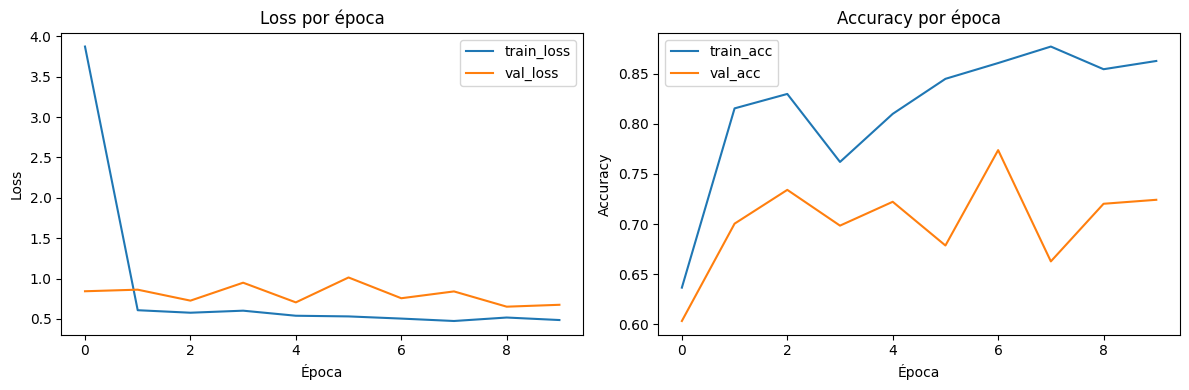

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    sem fogo       0.83      0.75      0.79       402
    com fogo       0.29      0.39      0.33       102

    accuracy                           0.68       504
   macro avg       0.56      0.57      0.56       504
weighted avg       0.72      0.68      0.70       504



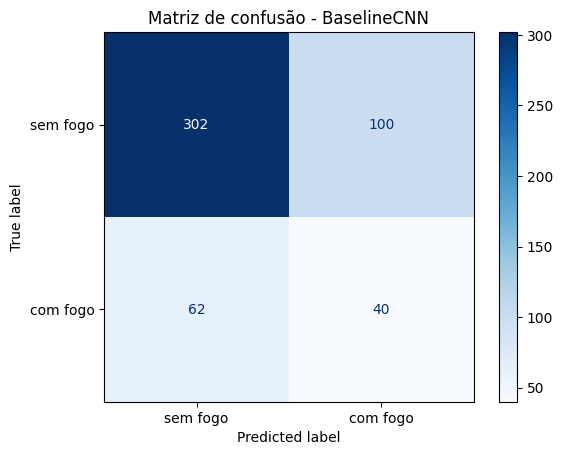

In [72]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    return np.array(all_targets), np.array(all_preds)

y_true_test, y_pred_test = predict_loader(model, test_loader, device)

print(classification_report(y_true_test, y_pred_test, target_names=["sem fogo", "com fogo"]))

cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["sem fogo", "com fogo"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão - BaselineCNN")
plt.show()

# 8. Modelo 2 — ImprovedCNN

Versão mais profunda da arquitetura, com mais camadas convolucionais e regularização adicional.

In [73]:
class ImprovedCNN(nn.Module):
    def __init__(self, in_channels=12, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model2 = ImprovedCNN().to(device)
model2

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.15, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, c

In [74]:
dummy_x, dummy_y = next(iter(train_loader))
out = model2(dummy_x.to(device))
print(out.shape)

torch.Size([8, 2])


In [75]:
criterion2 = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer2 = torch.optim.Adam(model2.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs_2 = 12
best_val_acc_2 = 0.0
best_state_2 = None

history2 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs_2 + 1):
    train_loss, train_acc = train_one_epoch(model2, train_loader, criterion2, optimizer2, device)
    val_loss, val_acc, y_true, y_pred = evaluate(model2, val_loader, criterion2, device)

    history2["train_loss"].append(train_loss)
    history2["train_acc"].append(train_acc)
    history2["val_loss"].append(val_loss)
    history2["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc_2:
        best_val_acc_2 = val_acc
        best_state_2 = deepcopy(model2.state_dict())

print("Best val acc:", best_val_acc_2)

Epoch 01 | train_loss=0.5674 train_acc=0.8306 | val_loss=0.6365 val_acc=0.6964
Epoch 02 | train_loss=0.5771 train_acc=0.8333 | val_loss=0.5963 val_acc=0.7321
Epoch 03 | train_loss=0.5428 train_acc=0.8594 | val_loss=0.7412 val_acc=0.7063
Epoch 04 | train_loss=0.5278 train_acc=0.8594 | val_loss=0.8029 val_acc=0.6647
Epoch 05 | train_loss=0.5174 train_acc=0.8615 | val_loss=0.8250 val_acc=0.7044
Epoch 06 | train_loss=0.5193 train_acc=0.8697 | val_loss=0.7337 val_acc=0.7698
Epoch 07 | train_loss=0.5040 train_acc=0.8896 | val_loss=0.7100 val_acc=0.7837
Epoch 08 | train_loss=0.4907 train_acc=0.8937 | val_loss=0.6013 val_acc=0.8175
Epoch 09 | train_loss=0.4875 train_acc=0.9026 | val_loss=0.5795 val_acc=0.8373
Epoch 10 | train_loss=0.4712 train_acc=0.8944 | val_loss=0.7779 val_acc=0.7937
Epoch 11 | train_loss=0.4764 train_acc=0.8992 | val_loss=0.5893 val_acc=0.8214
Epoch 12 | train_loss=0.4434 train_acc=0.9115 | val_loss=0.5484 val_acc=0.8373
Best val acc: 0.8373015873015873


In [76]:
torch.save(best_state_2, PROJECT_ROOT / "artifacts" / "improved_cnn_best.pt")

## Resultados da ImprovedCNN

              precision    recall  f1-score   support

    sem fogo       0.87      0.93      0.90       402
    com fogo       0.62      0.44      0.52       102

    accuracy                           0.83       504
   macro avg       0.75      0.69      0.71       504
weighted avg       0.82      0.83      0.82       504



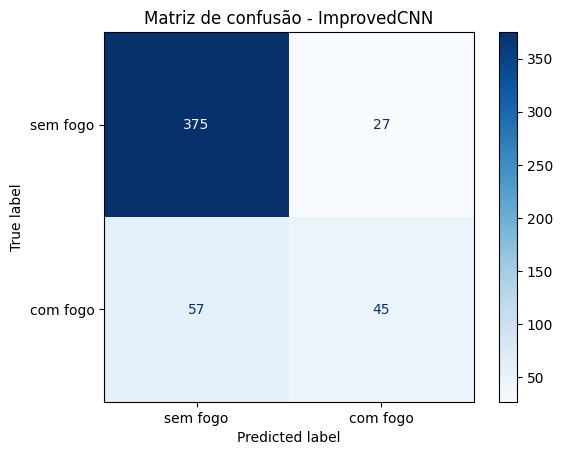

In [77]:
model2.load_state_dict(best_state_2)

y_true_test_2, y_pred_test_2 = predict_loader(model2, test_loader, device)

print(classification_report(y_true_test_2, y_pred_test_2, target_names=["sem fogo", "com fogo"]))

cm2 = confusion_matrix(y_true_test_2, y_pred_test_2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["sem fogo", "com fogo"])
disp2.plot(cmap="Blues")
plt.title("Matriz de confusão - ImprovedCNN")
plt.show()

### Comparação Parcial

Comparação inicial entre BaselineCNN e ImprovedCNN utilizando a métrica de validação.

# 9. Balanceamento de Classes

O dataset apresenta desbalanceamento entre patches com fogo e sem fogo.

Para reduzir esse problema é utilizado o WeightedRandomSampler.

In [79]:
from torch.utils.data import WeightedRandomSampler

train_labels = train_df["patch_label"].values

class_sample_count = np.array([
    (train_labels == 0).sum(),
    (train_labels == 1).sum()
])

weights = 1.0 / class_sample_count

sample_weights = np.array([
    weights[label] for label in train_labels
])

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_balanced = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=sampler
)

print("Classes no treino:")
print(class_sample_count)

print("\nPesos:")
print(weights)

batch_x, batch_y = next(iter(train_loader_balanced))

print("\nDistribuição do primeiro batch:")
print(batch_y)

Classes no treino:
[1305  153]

Pesos:
[0.00076628 0.00653595]

Distribuição do primeiro batch:
tensor([1, 1, 0, 1, 0, 0, 0, 0])


In [80]:
model3 = ImprovedCNN().to(device)

criterion3 = nn.CrossEntropyLoss()
optimizer3 = torch.optim.Adam(model3.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs_3 = 12
best_val_acc_3 = 0.0
best_state_3 = None

history3 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs_3 + 1):
    train_loss, train_acc = train_one_epoch(model3, train_loader_balanced, criterion3, optimizer3, device)
    val_loss, val_acc, y_true, y_pred = evaluate(model3, val_loader, criterion3, device)

    history3["train_loss"].append(train_loss)
    history3["train_acc"].append(train_acc)
    history3["val_loss"].append(val_loss)
    history3["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc_3:
        best_val_acc_3 = val_acc
        best_state_3 = deepcopy(model3.state_dict())

print("Best val acc:", best_val_acc_3)

torch.save(best_state_3, PROJECT_ROOT / "artifacts" / "improved_balanced_cnn_best.pt")

Epoch 01 | train_loss=0.5933 train_acc=0.6962 | val_loss=0.8214 val_acc=0.7004
Epoch 02 | train_loss=0.5287 train_acc=0.7497 | val_loss=0.6056 val_acc=0.7123
Epoch 03 | train_loss=0.5059 train_acc=0.7675 | val_loss=0.5572 val_acc=0.8095
Epoch 04 | train_loss=0.5157 train_acc=0.7805 | val_loss=0.5382 val_acc=0.7877
Epoch 05 | train_loss=0.4932 train_acc=0.7791 | val_loss=0.7105 val_acc=0.7103
Epoch 06 | train_loss=0.4752 train_acc=0.7881 | val_loss=0.5152 val_acc=0.7956
Epoch 07 | train_loss=0.4876 train_acc=0.7764 | val_loss=0.7460 val_acc=0.7024
Epoch 08 | train_loss=0.4584 train_acc=0.7970 | val_loss=0.8331 val_acc=0.6766
Epoch 09 | train_loss=0.4355 train_acc=0.8038 | val_loss=0.7333 val_acc=0.6925
Epoch 10 | train_loss=0.4158 train_acc=0.8196 | val_loss=1.2671 val_acc=0.6687
Epoch 11 | train_loss=0.4400 train_acc=0.7984 | val_loss=0.4161 val_acc=0.8075
Epoch 12 | train_loss=0.4449 train_acc=0.7853 | val_loss=1.1013 val_acc=0.6806
Best val acc: 0.8095238095238095


              precision    recall  f1-score   support

    sem fogo       0.87      0.87      0.87       402
    com fogo       0.48      0.47      0.48       102

    accuracy                           0.79       504
   macro avg       0.67      0.67      0.67       504
weighted avg       0.79      0.79      0.79       504



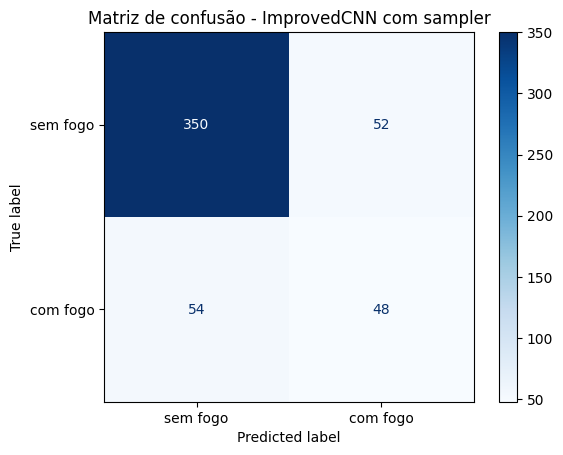

In [81]:
model3.load_state_dict(best_state_3)

y_true_test_3, y_pred_test_3 = predict_loader(model3, test_loader, device)

print(classification_report(y_true_test_3, y_pred_test_3, target_names=["sem fogo", "com fogo"]))

cm3 = confusion_matrix(y_true_test_3, y_pred_test_3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["sem fogo", "com fogo"])
disp3.plot(cmap="Blues")
plt.title("Matriz de confusão - ImprovedCNN com sampler")
plt.show()

# 10. Comparação Final dos Modelos

Avaliação consolidada dos três experimentos realizados.

In [82]:
summary_df = pd.DataFrame([
    {
        "Model": "BaselineCNN",
        "Best_Val_Acc": 0.7738,
        "Test_Accuracy": 0.68,
        "Fire_Precision": 0.29,
        "Fire_Recall": 0.39,
        "Fire_F1": 0.33
    },
    {
        "Model": "ImprovedCNN",
        "Best_Val_Acc": 0.8373,
        "Test_Accuracy": 0.83,
        "Fire_Precision": 0.62,
        "Fire_Recall": 0.44,
        "Fire_F1": 0.52
    },
    {
        "Model": "ImprovedCNN + WeightedRandomSampler",
        "Best_Val_Acc": 0.7282,
        "Test_Accuracy": 0.70,
        "Fire_Precision": 0.33,
        "Fire_Recall": 0.50,
        "Fire_F1": 0.40
    }
])

summary_df

,Model,Best_Val_Acc,Test_Accuracy,Fire_Precision,Fire_Recall,Fire_F1
0,BaselineCNN,0.7738,0.68,0.29,0.39,0.33
1,ImprovedCNN,0.8373,0.83,0.62,0.44,0.52
2,ImprovedCNN + WeightedRandomSampler,0.7282,0.70,0.33,0.50,0.40


In [83]:
summary_df.sort_values(
    by="Fire_F1",
    ascending=False
)

,Model,Best_Val_Acc,Test_Accuracy,Fire_Precision,Fire_Recall,Fire_F1
1,ImprovedCNN,0.8373,0.83,0.62,0.44,0.52
2,ImprovedCNN + WeightedRandomSampler,0.7282,0.70,0.33,0.50,0.40
0,BaselineCNN,0.7738,0.68,0.29,0.39,0.33


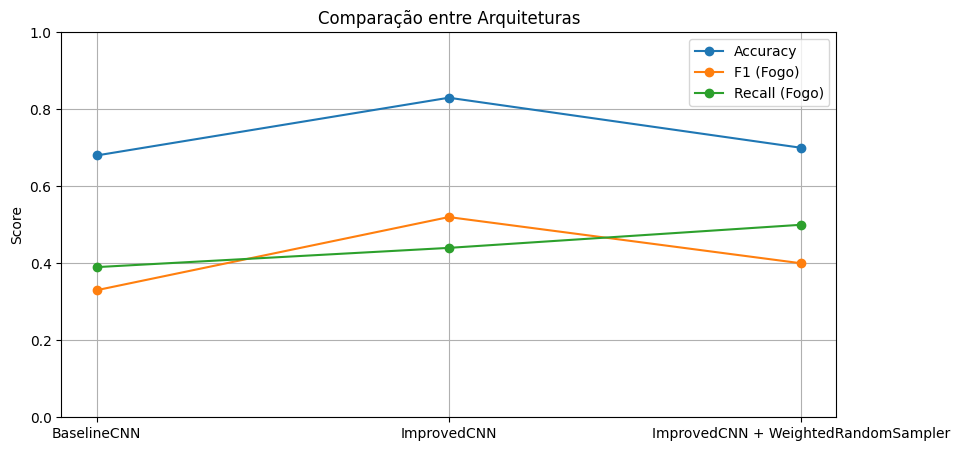

In [84]:
plt.figure(figsize=(10, 5))

models = summary_df["Model"]

plt.plot(models, summary_df["Test_Accuracy"], marker="o", label="Accuracy")
plt.plot(models, summary_df["Fire_F1"], marker="o", label="F1 (Fogo)")
plt.plot(models, summary_df["Fire_Recall"], marker="o", label="Recall (Fogo)")

plt.title("Comparação entre Arquiteturas")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

In [85]:
summary_df.to_csv(PROJECT_ROOT / "results" / "model_comparison.csv", index=False)
print("Tabela salva.")

Tabela salva.


In [86]:
plt.savefig(
    PROJECT_ROOT / "results" / "model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

print("Gráfico salvo.")

Gráfico salvo.


<Figure size 640x480 with 0 Axes>

# 11. Demonstração de Inferência

Teste do modelo final em um patch individual do conjunto de teste.

In [87]:
def predict_single_patch(file_path, model, device, img_size=128):
    with np.load(file_path, allow_pickle=True) as data:
        image = data["image"]
        label = data["label"]

    x = torch.tensor(image, dtype=torch.float32)
    x = torch.nn.functional.interpolate(
        x.unsqueeze(0),
        size=(img_size, img_size),
        mode="bilinear",
        align_corners=False
    ).squeeze(0)

    x = (x - x.mean()) / (x.std() + 1e-6)
    x = x.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()
        prob = torch.softmax(logits, dim=1)[0, pred].item()

    true_label = int((label > 0).any())
    return true_label, pred, prob

In [88]:
model_final = ImprovedCNN().to(device)
model_final.load_state_dict(best_state_2)
model_final.eval()

example_file = Path(test_df.iloc[0]["file_path"])
true_label, pred_label, prob = predict_single_patch(example_file, model_final, device)

print("Arquivo:", example_file.name)
print("Rótulo real:", "com fogo" if true_label == 1 else "sem fogo")
print("Predição:", "com fogo" if pred_label == 1 else "sem fogo")
print(f"Confiança: {prob:.2f}")

Arquivo: scene_4_patch_10_1.npz
Rótulo real: sem fogo
Predição: sem fogo
Confiança: 0.92


# 12. Conclusão

Foram avaliadas três abordagens para classificação de imagens de satélite no contexto de monitoramento de queimadas.

Resultados principais:

- BaselineCNN: desempenho inicial satisfatório.
- ImprovedCNN: melhor resultado geral.
- ImprovedCNN + WeightedRandomSampler: aumento do recall da classe fogo, porém com perda de desempenho global.

O modelo escolhido como solução final foi a ImprovedCNN, que apresentou o melhor equilíbrio entre accuracy, precision, recall e F1-score.

## Limitações e Trabalhos Futuros

Limitações:

- Dataset desbalanceado.
- Número limitado de cenas disponíveis.
- Classificação baseada apenas na presença ou ausência de fogo.

Possíveis melhorias:

- Data augmentation.
- Ajuste fino de hiperparâmetros.
- Arquiteturas mais avançadas (ResNet, EfficientNet).
- Segmentação semântica para localização precisa das áreas queimadas.